In [3]:
import pandas as pd
import numpy as np

In [4]:
users = pd.read_csv("Users.csv", low_memory=False)
books = pd.read_csv("Books.csv", low_memory=False)
ratings = pd.read_csv("Ratings.csv", low_memory=False)

In [5]:
print("Users shape:", users.shape)
print("Books shape:", books.shape)
print("Ratings shape:", ratings.shape)

Users shape: (278858, 3)
Books shape: (271360, 8)
Ratings shape: (1149780, 3)


In [6]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [7]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [8]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [9]:
print("Users columns:", users.columns)
print("Books columns:", books.columns)
print("Ratings columns:", ratings.columns)


Users columns: Index(['User-ID', 'Location', 'Age'], dtype='object')
Books columns: Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')
Ratings columns: Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object')


In [10]:
# Rename columns for easier work
users.rename(columns={
    'User-ID': 'user_id',
    'Location': 'location',
    'Age': 'age'
}, inplace=True)

books.rename(columns={
    'ISBN': 'isbn',
    'Book-Title': 'title',
    'Book-Author': 'author',
    'Year-Of-Publication': 'year',
    'Publisher': 'publisher',
    'Image-URL-S': 'img-s',
    'Image-URL-M':'img-m',
    'Image-URL-L':'img-l'
}, inplace=True)

ratings.rename(columns={
    'User-ID': 'user_id',
    'ISBN': 'isbn',
    'Book-Rating': 'rating'
}, inplace=True)

print("Users:", users.columns)
print("Books:", books.columns)
print("Ratings:", ratings.columns)


Users: Index(['user_id', 'location', 'age'], dtype='object')
Books: Index(['isbn', 'title', 'author', 'year', 'publisher', 'img-s', 'img-m',
       'img-l'],
      dtype='object')
Ratings: Index(['user_id', 'isbn', 'rating'], dtype='object')


1️⃣ Replacing Missing Ages

In [11]:
users['age'] = users['age'].fillna(users['age'].median())

2️⃣ Fixing wrong age values

In [12]:
users['age'] = users['age'].apply(lambda x: 30 if x < 5 or x > 100 else x)

3️⃣ Replacing missing book authors/publishers

In [13]:
books['author'] = books['author'].fillna("Unknown")
books['publisher'] = books['publisher'].fillna("Unknown")


4️⃣ Removing 0 Ratings

In [14]:
ratings = ratings[ratings['rating'] != 0]

In [15]:
# Merge ratings with users on user_id
data = ratings.merge(users, on='user_id', how='left')

In [16]:
# Merge the result with books on isbn
data = data.merge(books, on='isbn', how='left')

In [17]:
print("Merged data shape:", data.shape)
data.head()

Merged data shape: (433671, 12)


,user_id,isbn,rating,location,age,title,author,year,publisher,img-s,img-m,img-l
0,276726,0155061224,5,"seattle, washington, usa",32.0,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
1,276729,052165615X,3,"rijeka, n/a, croatia",16.0,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
2,276729,0521795028,6,"rijeka, n/a, croatia",16.0,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
3,276736,3257224281,8,"salzburg, salzburg, austria",32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,276737,0600570967,6,"sydney, new south wales, australia",14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Count ratings per user
user_rating_count = data['user_id'].value_counts()

# Keep users with >= 10 ratings
data = data[data['user_id'].isin(user_rating_count[user_rating_count >= 10].index)]

# Count ratings per book
book_rating_count = data['isbn'].value_counts()

# Keep books with >= 10 ratings
data = data[data['isbn'].isin(book_rating_count[book_rating_count >= 10].index)]

print("After filtering:", data.shape)

data.head()


After filtering: (74907, 12)


,user_id,isbn,rating,location,age,title,author,year,publisher,img-s,img-m,img-l
55,276822,0060096195,10,"calgary, alberta, canada",11.0,The Boy Next Door,Meggin Cabot,2002,Avon Trade,http://images.amazon.com/images/P/0060096195.0...,http://images.amazon.com/images/P/0060096195.0...,http://images.amazon.com/images/P/0060096195.0...
62,276822,0552546933,9,"calgary, alberta, canada",11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,276822,0786817070,10,"calgary, alberta, canada",11.0,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,2002,Miramax Kids,http://images.amazon.com/images/P/0786817070.0...,http://images.amazon.com/images/P/0786817070.0...,http://images.amazon.com/images/P/0786817070.0...
82,276847,3426029553,8,"köln, nordrhein-westfalen, germany",27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,276847,3551551677,10,"köln, nordrhein-westfalen, germany",27.0,Harry Potter und der Stein der Weisen,Joanne K. Rowling,1999,Carlsen Verlag GmbH,http://images.amazon.com/images/P/3551551677.0...,http://images.amazon.com/images/P/3551551677.0...,http://images.amazon.com/images/P/3551551677.0...


In [19]:
print("Total Rows:", data.shape[0])
print("Total Columns:", data.shape[1])
print("\nColumn Info:\n")
print(data.dtypes)

Total Rows: 74907
Total Columns: 12

Column Info:

user_id        int64
isbn          object
rating         int64
location      object
age          float64
title         object
author        object
year          object
publisher     object
img-s         object
img-m         object
img-l         object
dtype: object


In [20]:
print("\nMissing Values:\n")
print(data.isnull().sum())


Missing Values:

user_id         0
isbn            0
rating          0
location        0
age             0
title        1417
author       1417
year         1417
publisher    1417
img-s        1417
img-m        1417
img-l        1417
dtype: int64


In [21]:
print("Unique Users:", data['user_id'].nunique())
print("Unique Books:", data['isbn'].nunique())

Unique Users: 6570
Unique Books: 3411


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

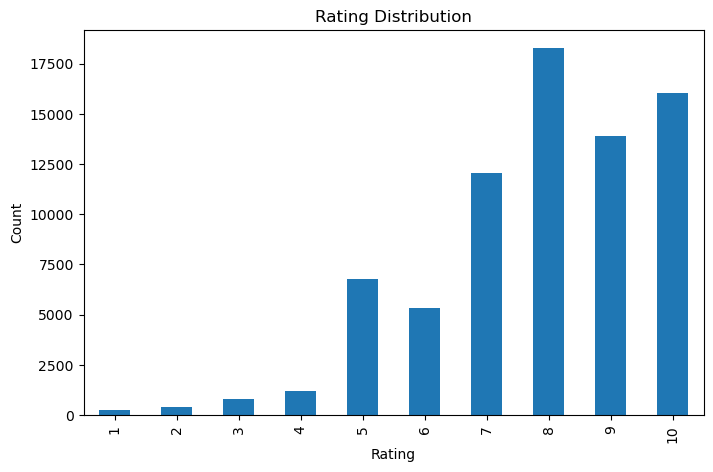

In [23]:
plt.figure(figsize=(8,5))
data['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

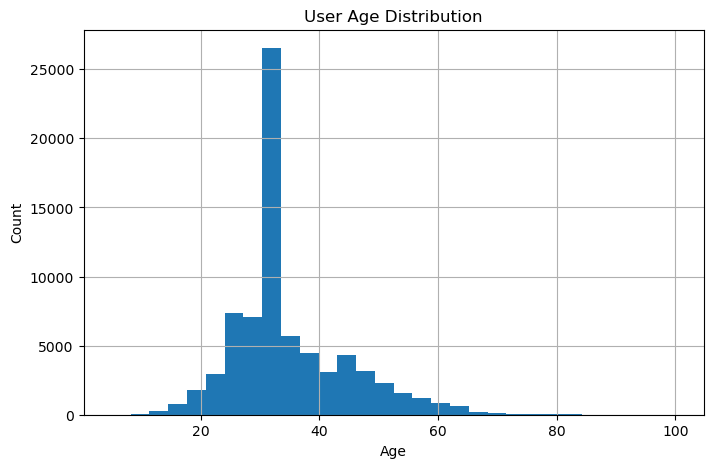

In [24]:
plt.figure(figsize=(8,5))
data['age'].hist(bins=30)
plt.title("User Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [25]:
top_books_count = data['title'].value_counts().head(10)

print("Top 10 Most Rated Books:")
print(top_books_count)


Top 10 Most Rated Books:
title
The Lovely Bones: A Novel                            337
The Da Vinci Code                                    276
Bridget Jones's Diary                                236
The Secret Life of Bees                              234
Harry Potter and the Chamber of Secrets (Book 2)     222
The Nanny Diaries: A Novel                           205
Harry Potter and the Prisoner of Azkaban (Book 3)    197
The Red Tent (Bestselling Backlist)                  196
Life of Pi                                           194
Wild Animus                                          194
Name: count, dtype: int64


In [26]:
book_stats = data.groupby('title').agg({
    'rating': ['mean', 'count']
})

book_stats.columns = ['avg_rating', 'rating_count']

# Keep only books with ≥30 ratings
filtered_stats = book_stats[book_stats['rating_count'] >= 30]

top_avg_books = filtered_stats.sort_values('avg_rating', ascending=False).head(10)

print("Top 10 Highest Rated Books (min 30 ratings):")
top_avg_books


Top 10 Highest Rated Books (min 30 ratings):


,avg_rating,rating_count
title,,
"The Return of the King (The Lord of the Rings, Part 3)",9.462963,54
"The Two Towers (The Lord of the Rings, Part 2)",9.428571,77
Harry Potter and the Goblet of Fire (Book 4),9.241573,178
The Little Prince,9.122449,49
Harry Potter and the Prisoner of Azkaban (Book 3),9.116751,197
Griffin &amp; Sabine: An Extraordinary Correspondence,9.097561,41
Charlotte's Web (Trophy Newbery),9.068182,44
Harry Potter and the Sorcerer's Stone (Book 1),9.057377,122
Harry Potter and the Order of the Phoenix (Book 5),9.056962,158


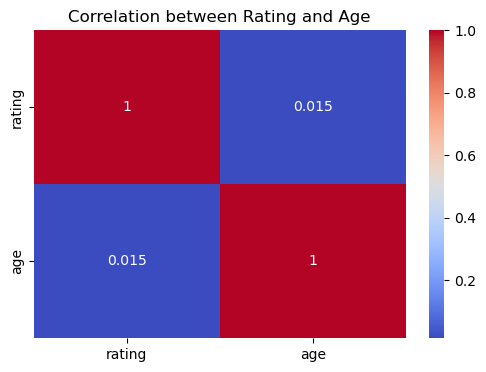

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(data[['rating','age']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Rating and Age")
plt.show()


In [28]:
print("Final Clean Data Summary:")
print(data.describe(include='all'))

Final Clean Data Summary:
              user_id        isbn        rating       location           age  \
count    74907.000000       74907  74907.000000          74907  74907.000000   
unique            NaN        3411           NaN           3403           NaN   
top               NaN  0316666343           NaN  n/a, n/a, n/a           NaN   
freq              NaN         337           NaN           1375           NaN   
mean    137631.796761         NaN      7.871694            NaN     34.833407   
std      80692.646516         NaN      1.771285            NaN      9.877338   
min        242.000000         NaN      1.000000            NaN      5.000000   
25%      69078.000000         NaN      7.000000            NaN     30.000000   
50%     135376.000000         NaN      8.000000            NaN     32.000000   
75%     209147.000000         NaN      9.000000            NaN     39.000000   
max     278851.000000         NaN     10.000000            NaN    100.000000   

             

In [29]:
# Remove rows where title is missing (NaN)
data = data.dropna(subset=['title'])

print("After removing missing book rows:", data.shape)


After removing missing book rows: (73490, 12)


In [30]:
book_features = data.groupby('title').agg({
    'rating': ['count', 'mean']
})

book_features.columns = ['rating_count', 'avg_rating']

# Sort books by rating count (most popular first)
book_features = book_features.sort_values('rating_count', ascending=False)

book_features.head(10)


,rating_count,avg_rating
title,,
The Lovely Bones: A Novel,337,8.246291
The Da Vinci Code,276,8.565217
Bridget Jones's Diary,236,7.690678
The Secret Life of Bees,234,8.611111
Harry Potter and the Chamber of Secrets (Book 2),222,8.909910
The Nanny Diaries: A Novel,205,7.336585
Harry Potter and the Prisoner of Azkaban (Book 3),197,9.116751
The Red Tent (Bestselling Backlist),196,8.382653
Life of Pi,194,8.211340


In [31]:
data = data.merge(book_features, on='title', how='left')
data.head()


,user_id,isbn,rating,location,age,title,author,year,publisher,img-s,img-m,img-l,rating_count,avg_rating
0,276822,0060096195,10,"calgary, alberta, canada",11.0,The Boy Next Door,Meggin Cabot,2002,Avon Trade,http://images.amazon.com/images/P/0060096195.0...,http://images.amazon.com/images/P/0060096195.0...,http://images.amazon.com/images/P/0060096195.0...,33,8.303030
1,276822,0786817070,10,"calgary, alberta, canada",11.0,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,2002,Miramax Kids,http://images.amazon.com/images/P/0786817070.0...,http://images.amazon.com/images/P/0786817070.0...,http://images.amazon.com/images/P/0786817070.0...,77,7.714286
2,276847,3551551677,10,"köln, nordrhein-westfalen, germany",27.0,Harry Potter und der Stein der Weisen,Joanne K. Rowling,1999,Carlsen Verlag GmbH,http://images.amazon.com/images/P/3551551677.0...,http://images.amazon.com/images/P/3551551677.0...,http://images.amazon.com/images/P/3551551677.0...,12,9.083333
3,276847,3551551685,10,"köln, nordrhein-westfalen, germany",27.0,Harry Potter und die Kammer des Schreckens,Joanne K. Rowling,2000,Carlsen Verlag GmbH,http://images.amazon.com/images/P/3551551685.0...,http://images.amazon.com/images/P/3551551685.0...,http://images.amazon.com/images/P/3551551685.0...,10,9.200000
4,276861,3423201509,10,"zauggenried, bern, switzerland",17.0,Die Weiss Lowin / Contemporary German Lit,Henning Mankell,2002,Distribooks,http://images.amazon.com/images/P/3423201509.0...,http://images.amazon.com/images/P/3423201509.0...,http://images.amazon.com/images/P/3423201509.0...,13,8.076923


In [33]:
data.shape

(73490, 14)